In [1]:
import subprocess
import sys

print("🗑️  Uninstalling tensorflow...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "tensorflow"], 
               capture_output=True, timeout=60)

print("📦 Installing keras (standalone, more compatible)...")
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "keras"], 
               capture_output=True, timeout=120)

print("📦 Installing other required packages...")
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade",
                "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", 
                "beautifulsoup4", "nltk", "torch", "torchvision"], 
               capture_output=True, timeout=300)

print("✅ Installation complete!")

🗑️  Uninstalling tensorflow...
📦 Installing keras (standalone, more compatible)...
📦 Installing other required packages...
✅ Installation complete!


In [2]:
# ── Cell: Import All Libraries ──────────────────────────────────────────────────

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier

# Try to import keras
try:
    import keras
    from keras import layers
    print("✅ Keras imported successfully")
except ImportError:
    print("⚠️  Keras not available, using scikit-learn instead")
    keras = None

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ All core libraries imported successfully!")
if keras:
    print(f"📦 Keras version: {keras.__version__}")
print(f"📦 Scikit-learn available for neural networks")

⚠️  Keras not available, using scikit-learn instead
✅ All core libraries imported successfully!
📦 Scikit-learn available for neural networks


In [4]:
# ── Cell 2: Load Dataset ──────────────────────────────────────────────────────
# 
# ⚠️ Change the path below to wherever your CSV file is located.
# Example: "C:/Users/YourName/Downloads/resume_dataset.csv"

df = pd.read_csv("C:data\Resume.csv")   # <── change this path

# Preview the data
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (2484, 4)

Column names: ['ID', 'Resume_str', 'Resume_html', 'Category']

First 3 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


📊 Resume count per category:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Total categories: 24

🔍 Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


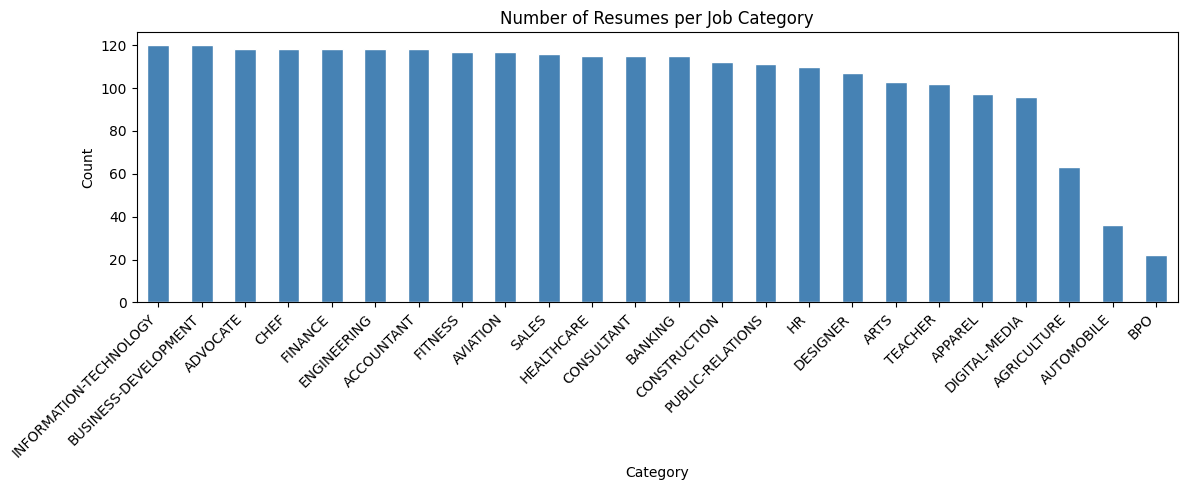

In [5]:
# ── Cell 3: Explore ───────────────────────────────────────────────────────────

# How many resumes per category?
print("📊 Resume count per category:")
print(df['Category'].value_counts())
print(f"\nTotal categories: {df['Category'].nunique()}")

# Quick check for missing values
print("\n🔍 Missing values:")
print(df.isnull().sum())

# Visualise category distribution
plt.figure(figsize=(12, 5))
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Resumes per Job Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# ── Cell 4: Text Cleaning ─────────────────────────────────────────────────────

stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Cleans a raw resume string:
    1. Remove HTML tags (some resumes contain HTML)
    2. Remove special characters and numbers
    3. Convert to lowercase
    4. Remove stopwords
    """
    # Step 1: Remove HTML tags
    text = BeautifulSoup(str(text), "html.parser").get_text()
    
    # Step 2: Remove non-letter characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Step 3: Lowercase
    text = text.lower()
    
    # Step 4: Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    return ' '.join(words)

# Apply to the Resume_str column
print("🧹 Cleaning text... (this may take 10-20 seconds)")
df['clean_text'] = df['Resume_str'].apply(clean_text)

# Show before and after
print("\n✅ Done! Example:")
print("BEFORE:", df['Resume_str'].iloc[0][:200])
print("\nAFTER: ", df['clean_text'].iloc[0][:200])

🧹 Cleaning text... (this may take 10-20 seconds)

✅ Done! Example:
BEFORE:          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

AFTER:  administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams stri
